# 22 — Final Ablation Analysis and Presentation Artifacts

This notebook is the final reporting stage of the text-assisted temporal
action segmentation project. It performs **no feature extraction and no
model training**. It reads the completed summaries from the Breakfast
and Assembly101 pipelines and produces:

- protocol and inference-contract audit;
- tables grouped by architecture, strategy, and hyperparameter;
- presentation-ready figures;
- cross-dataset comparisons;
- loss definitions and interpretation notes;
- concise conclusions and limitations;
- an eight-slide presentation outline;
- a ZIP archive containing all generated artifacts.

The primary Assembly101 model is selected only by validation:
MS-TCN video-only KD student with `lambda_KD=0.2`, `T=4`, and
all-stage distillation. Test metrics are reported but never used for
hyperparameter selection.


## Reporting questions

1. Which temporal architecture and video representation form the
   strongest visual-only baseline?
2. How large is the privileged-text teacher upper bound?
3. Does logit KD improve the deployable video-only student?
4. Does a learnable text-prototype objective help independently?
5. Are text alignment and KD complementary when optimized jointly?
6. Are the conclusions consistent across Breakfast and Assembly101?

Primary metric: segmental `F1@25`. Accuracy, Edit, `F1@10`, and
`F1@50` are retained so that improvements are not presented as uniform
when they are metric-specific.


## 1. Mount Google Drive


In [1]:
from google.colab import drive

drive.mount("/content/drive")


Mounted at /content/drive


## 2. Imports and output configuration


In [2]:
from pathlib import Path
from datetime import datetime, timezone

import json
import math
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 220)
pd.set_option("display.max_colwidth", 280)
pd.set_option("display.width", 220)

DRIVE_ROOT = Path("/content/drive/MyDrive/mmf_tas_lab_data")
PROJECT_ROOT = DRIVE_ROOT / "text_assisted_tas"

BREAKFAST_ROOT = PROJECT_ROOT / "breakfast" / "procedurevrl_hidden"
ASSEMBLY_ROOT = (
    PROJECT_ROOT
    / "assembly101"
    / "coarse_mstcn_format"
    / "streaming_visual_features_v1"
)

OUT_ROOT = PROJECT_ROOT / "final_report_artifacts" / "notebook22"
TABLE_DIR = OUT_ROOT / "tables"
FIGURE_DIR = OUT_ROOT / "figures"
TEXT_DIR = OUT_ROOT / "text"

for directory in [OUT_ROOT, TABLE_DIR, FIGURE_DIR, TEXT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

ARCHIVE_PATH = OUT_ROOT.parent / "notebook22_presentation_artifacts.zip"

METRICS = ["acc", "edit", "f1@10", "f1@25", "f1@50"]
PRIMARY_METRIC = "f1@25"

COLORS = {
    "visual": "#4C78A8",
    "ce": "#9D9D9D",
    "kd": "#F58518",
    "text": "#54A24B",
    "combined": "#B279A2",
    "teacher": "#E45756",
}

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 200,
        "font.size": 10,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.fontsize": 9,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": False,
    }
)

print("OUT_ROOT:", OUT_ROOT)
print("This notebook trains models:", False)


OUT_ROOT: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22
This notebook trains models: False


## 3. Resolve summary files


In [3]:
def resolve_summary(label, preferred, fallback_pattern=None):
    preferred = Path(preferred)
    if preferred.exists():
        print(f"{label}: {preferred}")
        return preferred

    candidates = []
    if fallback_pattern is not None:
        base, pattern = fallback_pattern
        candidates = sorted(Path(base).glob(pattern))

    completed_candidates = []
    for candidate in candidates:
        try:
            payload = json.loads(candidate.read_text(encoding="utf-8"))
            if payload.get("status") == "completed":
                completed_candidates.append(candidate)
        except Exception:
            continue

    if len(completed_candidates) == 1:
        print(f"{label} (fallback): {completed_candidates[0]}")
        return completed_candidates[0]

    raise FileNotFoundError(
        f"Could not resolve {label}. Preferred={preferred}; "
        f"completed fallbacks={completed_candidates}"
    )


SUMMARY_PATHS = {
    "breakfast_10": resolve_summary(
        "Breakfast notebook 10",
        BREAKFAST_ROOT
        / "runs"
        / "mstcn_hidden_baseline_split1"
        / "results"
        / "final_summary.json",
    ),
    "breakfast_11": resolve_summary(
        "Breakfast notebook 11",
        BREAKFAST_ROOT
        / "runs"
        / "procedurevrl_hidden_privileged_text_teacher_kd_full_split1_split1"
        / "results"
        / "final_summary.json",
        (
            BREAKFAST_ROOT / "runs",
            "procedurevrl_hidden_privileged_text_teacher_kd*/results/final_summary.json",
        ),
    ),
    "assembly_16": resolve_summary(
        "Assembly101 notebook 16",
        ASSEMBLY_ROOT
        / "runs"
        / "16_visual_only_mstcn"
        / "final_summary_full.json",
    ),
    "assembly_17": resolve_summary(
        "Assembly101 notebook 17",
        ASSEMBLY_ROOT
        / "runs"
        / "17_visual_only_ltcontext"
        / "final_summary_full.json",
    ),
    "assembly_18": resolve_summary(
        "Assembly101 notebook 18",
        ASSEMBLY_ROOT
        / "runs"
        / "18_text_assisted_concat_teachers"
        / "final_summary_full.json",
    ),
    "assembly_19": resolve_summary(
        "Assembly101 notebook 19",
        ASSEMBLY_ROOT
        / "runs"
        / "19_video_only_kd_students"
        / "full"
        / "final_summary.json",
    ),
    "assembly_20": resolve_summary(
        "Assembly101 notebook 20",
        ASSEMBLY_ROOT
        / "runs"
        / "20_learnable_text_students"
        / "full"
        / "final_summary.json",
    ),
    "assembly_21": resolve_summary(
        "Assembly101 notebook 21",
        ASSEMBLY_ROOT
        / "runs"
        / "21_text_student_kd_search"
        / "full"
        / "final_summary.json",
    ),
}

print("Resolved summaries:", len(SUMMARY_PATHS))


Breakfast notebook 10: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/breakfast/procedurevrl_hidden/runs/mstcn_hidden_baseline_split1/results/final_summary.json
Breakfast notebook 11: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/breakfast/procedurevrl_hidden/runs/procedurevrl_hidden_privileged_text_teacher_kd_full_split1_split1/results/final_summary.json
Assembly101 notebook 16: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/16_visual_only_mstcn/final_summary_full.json
Assembly101 notebook 17: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/17_visual_only_ltcontext/final_summary_full.json
Assembly101 notebook 18: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/18_text_assisted_concat_teachers/final_summary_full.json
Assembly101 notebook 

## 4. Load summaries and audit completion


In [4]:
summaries = {
    name: json.loads(path.read_text(encoding="utf-8"))
    for name, path in SUMMARY_PATHS.items()
}

n10 = summaries["breakfast_10"]
n11 = summaries["breakfast_11"]
n16 = summaries["assembly_16"]
n17 = summaries["assembly_17"]
n18 = summaries["assembly_18"]
n19 = summaries["assembly_19"]
n20 = summaries["assembly_20"]
n21 = summaries["assembly_21"]

for name, summary in summaries.items():
    if summary.get("status") != "completed":
        raise RuntimeError(f"{name} is not completed: {summary.get('status')}")

if n21["search_protocol"]["test_used_for_search"] is not False:
    raise RuntimeError("Notebook 21 reports test use during search.")
if n21["inference_contract"]["external_text_input"] is not False:
    raise RuntimeError("Selected Assembly101 inference is not video-only.")
if n21["inference_contract"]["teacher_called"] is not False:
    raise RuntimeError("Teacher is called during final inference.")

assembly_final_rows = pd.DataFrame(n21["final_comparison"])
invalid_deployable_rows = assembly_final_rows[
    (assembly_final_rows["deployable"] == True)
    & (assembly_final_rows["inference_text"] == True)
]
if not invalid_deployable_rows.empty:
    raise RuntimeError(
        "A deployable Assembly101 row still uses text at inference."
    )

selected_prediction_count = int(
    n21["selected_kd_test"]["prediction_files"]
)
combined_prediction_count = int(
    n21["combined"]["test"]["prediction_files"]
)
expected_test_sequences = int(n21["data"]["test_sequences"])
if selected_prediction_count != expected_test_sequences:
    raise RuntimeError("Selected KD prediction count is incomplete.")
if combined_prediction_count != expected_test_sequences:
    raise RuntimeError("Combined prediction count is incomplete.")

audit_rows = []
for name, summary in summaries.items():
    audit_rows.append(
        {
            "summary": name,
            "status": summary.get("status"),
            "run_mode": summary.get("run_mode", "not recorded"),
            "path": str(SUMMARY_PATHS[name]),
        }
    )

audit_df = pd.DataFrame(audit_rows)
audit_df["validation_only_selection"] = "documented"
audit_df.loc[
    audit_df["summary"].isin(["breakfast_10", "breakfast_11"]),
    "validation_only_selection",
] = "legacy split protocol"

audit_path = TABLE_DIR / "00_completion_and_protocol_audit.csv"
audit_df.to_csv(audit_path, index=False)

display(audit_df)
print("Assembly101 test predictions:", expected_test_sequences)
print("Final inference input:", "video only")
print("Test used for hyperparameter search:", False)
print("Saved:", audit_path)


,summary,status,run_mode,path,validation_only_selection
0,breakfast_10,completed,not recorded,/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/breakfast/procedurevrl_hidden/runs/mstcn_hidden_baseline_split1/results/final_summary.json,legacy split protocol
1,breakfast_11,completed,full_split1,/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/breakfast/procedurevrl_hidden/runs/procedurevrl_hidden_privileged_text_teacher_kd_full_split1_split1/results/final_summary.json,legacy split protocol
2,assembly_16,completed,full,/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/16_visual_only_mstcn/final_summary_full.json,documented
3,assembly_17,completed,full,/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/17_visual_only_ltcontext/final_summary_full.json,documented
4,assembly_18,completed,full,/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/18_text_assisted_concat_teachers/final_summary_full.json,documented
5,assembly_19,completed,full,/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/19_video_only_kd_students/full/final_summary.json,documented
6,assembly_20,completed,full,/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/20_learnable_text_students/full/final_summary.json,documented
7,assembly_21,completed,full,/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/21_text_student_kd_search/full/final_summary.json,documented


Assembly101 test predictions: 167
Final inference input: video only
Test used for hyperparameter search: False
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/tables/00_completion_and_protocol_audit.csv


## 5. Shared table helpers


In [5]:
def write_table(dataframe, stem):
    csv_path = TABLE_DIR / f"{stem}.csv"
    markdown_path = TABLE_DIR / f"{stem}.md"
    dataframe.to_csv(csv_path, index=False)
    try:
        markdown_text = dataframe.to_markdown(index=False)
    except Exception:
        markdown_text = "```text\n" + dataframe.to_string(index=False) + "\n```"
    markdown_path.write_text(markdown_text + "\n", encoding="utf-8")
    print("Saved:", csv_path)
    print("Saved:", markdown_path)
    return csv_path, markdown_path


def metric_columns(prefix):
    return [f"{prefix}_{metric}" for metric in METRICS]


def metric_payload(metrics, prefix):
    return {
        f"{prefix}_{metric}": float(metrics[metric])
        for metric in METRICS
    }


def row_by_group(dataframe, group):
    matches = dataframe[dataframe["group"] == group]
    if len(matches) != 1:
        raise RuntimeError(f"Expected one row for group={group}, found {len(matches)}")
    return matches.iloc[0]


print("Table helpers ready.")


Table helpers ready.


## 6. Assembly101 architecture × representation grid


In [6]:
architecture_rows = []

for temporal_model, summary in [("MS-TCN", n16), ("LTContext", n17)]:
    for representation, experiment in summary["representations"].items():
        architecture_rows.append(
            {
                "dataset": "Assembly101",
                "group": "visual baseline",
                "temporal_model": temporal_model,
                "representation": representation,
                "strategy": "visual-only",
                "deployable": True,
                "inference_input": "video only",
                "best_epoch": int(experiment["training"]["best_epoch"]),
                **metric_payload(experiment["validation_metrics"], "val"),
                **metric_payload(experiment["test_metrics"], "test"),
            }
        )

for experiment_key, experiment in n18["experiments"].items():
    temporal_model, representation = experiment_key.split("/", maxsplit=1)
    architecture_rows.append(
        {
            "dataset": "Assembly101",
            "group": "privileged teacher",
            "temporal_model": (
                "MS-TCN" if temporal_model == "mstcn" else "LTContext"
            ),
            "representation": representation,
            "strategy": "video + GT-text concat teacher",
            "deployable": False,
            "inference_input": "video + ground-truth text",
            "best_epoch": int(experiment["training"]["best_epoch"]),
            **metric_payload(experiment["validation_metrics"], "val"),
            **metric_payload(experiment["test_metrics"], "test"),
        }
    )

architecture_df = (
    pd.DataFrame(architecture_rows)
    .sort_values(
        ["group", "test_f1@25", "test_edit"],
        ascending=[True, False, False],
    )
    .reset_index(drop=True)
)
architecture_df["rank_within_group_by_test_f1@25"] = (
    architecture_df.groupby("group")["test_f1@25"]
    .rank(method="min", ascending=False)
    .astype(int)
)

visual_architecture_df = architecture_df[
    architecture_df["group"] == "visual baseline"
].copy()
best_visual_row = visual_architecture_df.sort_values(
    ["test_f1@25", "test_edit"], ascending=False
).iloc[0]

write_table(architecture_df, "01_assembly_architecture_representation_grid")
display(architecture_df)
print(
    "Best visual baseline:",
    best_visual_row["temporal_model"],
    best_visual_row["representation"],
    "test F1@25=",
    best_visual_row["test_f1@25"],
)


Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/tables/01_assembly_architecture_representation_grid.csv
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/tables/01_assembly_architecture_representation_grid.md


,dataset,group,temporal_model,representation,strategy,deployable,inference_input,best_epoch,val_acc,val_edit,val_f1@10,val_f1@25,val_f1@50,test_acc,test_edit,test_f1@10,test_f1@25,test_f1@50,rank_within_group_by_test_f1@25
0,Assembly101,privileged teacher,MS-TCN,clip_vitb16,video + GT-text concat teacher,False,video + ground-truth text,120,45.21,34.92,39.73,38.25,34.14,44.27,37.39,41.65,40.94,36.81,1
1,Assembly101,privileged teacher,MS-TCN,procedurevrl_hidden,video + GT-text concat teacher,False,video + ground-truth text,105,42.86,33.61,37.20,36.01,32.24,41.39,32.70,37.41,35.96,31.93,2
2,Assembly101,privileged teacher,LTContext,clip_vitb16,video + GT-text concat teacher,False,video + ground-truth text,95,37.86,28.61,32.81,29.78,21.20,34.51,27.34,31.37,26.98,20.38,3
3,Assembly101,privileged teacher,LTContext,procedurevrl_hidden,video + GT-text concat teacher,False,video + ground-truth text,105,38.33,29.70,33.93,29.99,22.11,35.25,26.40,31.61,26.80,19.27,4
4,Assembly101,visual baseline,MS-TCN,clip_vitb16,visual-only,True,video only,110,29.95,26.01,29.23,25.90,18.97,25.86,25.01,28.00,23.82,17.58,1
5,Assembly101,visual baseline,MS-TCN,procedurevrl_hidden,visual-only,True,video only,70,30.26,24.17,28.88,25.15,18.70,26.16,24.74,28.36,23.79,15.72,2
6,Assembly101,visual baseline,LTContext,clip_vitb16,visual-only,True,video only,105,30.78,23.82,26.83,23.53,16.13,27.10,22.70,25.62,21.96,13.39,3
7,Assembly101,visual baseline,LTContext,procedurevrl_hidden,visual-only,True,video only,80,29.64,22.58,26.35,23.01,14.98,27.10,22.80,25.11,20.05,11.92,4


Best visual baseline: MS-TCN clip_vitb16 test F1@25= 23.82


## 7. Assembly101 strategy comparison


In [7]:
assembly_strategy_df = pd.DataFrame(n21["final_comparison"]).copy()
deployable_mask = assembly_strategy_df["deployable"] == True
assembly_strategy_df["rank_deployable_by_f1@25"] = np.nan
assembly_strategy_df.loc[
    deployable_mask, "rank_deployable_by_f1@25"
] = (
    assembly_strategy_df.loc[deployable_mask, "f1@25"]
    .rank(method="min", ascending=False)
    .astype(int)
)
assembly_strategy_df["selected_by_validation"] = False
assembly_strategy_df.loc[
    assembly_strategy_df["group"] == "expanded KD",
    "selected_by_validation",
] = (
    n21["recommended_deployable_strategy"]
    == "notebook21_selected_kd"
)

assembly_strategy_df = assembly_strategy_df.sort_values(
    ["deployable", "f1@25"], ascending=[False, False]
).reset_index(drop=True)

write_table(assembly_strategy_df, "02_assembly_strategy_comparison")
display(assembly_strategy_df)

selected_assembly_row = row_by_group(assembly_strategy_df, "expanded KD")
combined_assembly_row = row_by_group(assembly_strategy_df, "combined")
text_assembly_row = row_by_group(assembly_strategy_df, "text embedding")
old_kd_assembly_row = row_by_group(assembly_strategy_df, "original KD")
ce_assembly_row = row_by_group(assembly_strategy_df, "controlled student")
teacher_assembly_row = row_by_group(assembly_strategy_df, "oracle teacher")

print("Validation-selected strategy:", n21["recommended_deployable_strategy"])
print("Selected test F1@25:", selected_assembly_row["f1@25"])
print("Combined test F1@25:", combined_assembly_row["f1@25"])


Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/tables/02_assembly_strategy_comparison.csv
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/tables/02_assembly_strategy_comparison.md


,group,strategy,hyperparameters,training_text,inference_text,deployable,acc,edit,f1@10,f1@25,f1@50,rank_deployable_by_f1@25,selected_by_validation
0,expanded KD,MS-TCN selected KD student (notebook 21),"lambda=0.2, T=4.0, policy=all",True,False,True,25.67,25.10,28.22,24.11,17.36,1.0,True
1,architecture baseline,MS-TCN visual-only (notebook 16),CE,False,False,True,25.86,25.01,28.00,23.82,17.58,2.0,False
2,text embedding,MS-TCN text-aligned student (notebook 20),"learnable, beta=0.01",True,False,True,26.27,24.78,28.58,23.76,17.56,3.0,False
3,original KD,MS-TCN KD student (notebook 19),"lambda=0.1, T=4.0, all stages",True,False,True,26.38,24.64,28.40,23.75,17.73,4.0,False
4,combined,MS-TCN text + KD student (notebook 21),"beta=0.01, lambda=0.2, T=4.0, policy=all",True,False,True,26.24,24.85,28.73,23.67,17.32,5.0,False
5,controlled student,MS-TCN CE-only (notebook 19),lambda_KD=0,False,False,True,25.94,24.75,27.58,23.14,16.53,6.0,False
6,oracle teacher,MS-TCN concat teacher (notebook 18),video + GT text,True,True,False,44.27,37.39,41.65,40.94,36.81,NaN,False


Validation-selected strategy: notebook21_selected_kd
Selected test F1@25: 24.11
Combined test F1@25: 23.67


## 8. Hyperparameter ablation tables


In [8]:
stage_a_df = pd.read_csv(Path(n21["paths"]["stage_a_search"]))
stage_b_df = pd.read_csv(Path(n21["paths"]["stage_b_search"]))
stage_c_df = pd.read_csv(Path(n21["paths"]["stage_c_search"]))
text_ablation_df = pd.read_csv(Path(n20["paths"]["validation_ablation"]))

forbidden_test_columns = [
    column
    for dataframe in [stage_a_df, stage_b_df, stage_c_df, text_ablation_df]
    for column in dataframe.columns
    if column.startswith("test_")
]
if forbidden_test_columns:
    raise RuntimeError(
        f"A hyperparameter table contains test columns: {forbidden_test_columns}"
    )

stage_a_df = stage_a_df.sort_values("kd_lambda").reset_index(drop=True)
stage_b_df = stage_b_df.sort_values("temperature").reset_index(drop=True)
stage_c_df = stage_c_df.sort_values("stage_policy").reset_index(drop=True)
text_ablation_df = text_ablation_df.sort_values(
    ["strategy", "text_beta"]
).reset_index(drop=True)

write_table(stage_a_df, "03a_kd_lambda_ablation")
write_table(stage_b_df, "03b_kd_temperature_ablation")
write_table(stage_c_df, "03c_kd_stage_policy_ablation")
write_table(text_ablation_df, "03d_text_embedding_ablation")

hyperparameter_rows = []
for _, row in stage_a_df.iterrows():
    hyperparameter_rows.append(
        {
            "ablation": "KD coefficient",
            "candidate": f"lambda={row['kd_lambda']:g}",
            "fixed_context": "T=4, all stages",
            "val_acc": row["val_acc"],
            "val_edit": row["val_edit"],
            "val_f1@25": row["val_f1@25"],
            "val_f1@50": row["val_f1@50"],
            "selection_score": row["selection_score"],
        }
    )
for _, row in stage_b_df.iterrows():
    hyperparameter_rows.append(
        {
            "ablation": "KD temperature",
            "candidate": f"T={row['temperature']:g}",
            "fixed_context": "lambda=0.2, all stages",
            "val_acc": row["val_acc"],
            "val_edit": row["val_edit"],
            "val_f1@25": row["val_f1@25"],
            "val_f1@50": row["val_f1@50"],
            "selection_score": row["selection_score"],
        }
    )
for _, row in stage_c_df.iterrows():
    hyperparameter_rows.append(
        {
            "ablation": "KD stage policy",
            "candidate": str(row["stage_policy"]),
            "fixed_context": "lambda=0.2, T=4",
            "val_acc": row["val_acc"],
            "val_edit": row["val_edit"],
            "val_f1@25": row["val_f1@25"],
            "val_f1@50": row["val_f1@50"],
            "selection_score": row["selection_score"],
        }
    )
for _, row in text_ablation_df.iterrows():
    hyperparameter_rows.append(
        {
            "ablation": "Text prototypes",
            "candidate": f"{row['strategy']}, beta={row['text_beta']:g}",
            "fixed_context": "no KD",
            "val_acc": row["val_acc"],
            "val_edit": row["val_edit"],
            "val_f1@25": row["val_f1@25"],
            "val_f1@50": row["val_f1@50"],
            "selection_score": row["selection_score"],
        }
    )

hyperparameter_df = pd.DataFrame(hyperparameter_rows)
write_table(hyperparameter_df, "03_all_hyperparameter_ablations")
display(hyperparameter_df)


Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/tables/03a_kd_lambda_ablation.csv
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/tables/03a_kd_lambda_ablation.md
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/tables/03b_kd_temperature_ablation.csv
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/tables/03b_kd_temperature_ablation.md
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/tables/03c_kd_stage_policy_ablation.csv
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/tables/03c_kd_stage_policy_ablation.md
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/tables/03d_text_embedding_ablation.csv
Saved: /content/drive/MyDrive/mmf_tas_lab_dat

,ablation,candidate,fixed_context,val_acc,val_edit,val_f1@25,val_f1@50,selection_score
0,KD coefficient,lambda=0.01,"T=4, all stages",29.95,25.89,24.65,18.39,24.907668
1,KD coefficient,lambda=0.05,"T=4, all stages",30.00,25.99,24.97,18.18,25.227876
2,KD coefficient,lambda=0.1,"T=4, all stages",29.90,26.25,25.02,18.47,25.278568
3,KD coefficient,lambda=0.2,"T=4, all stages",30.42,26.36,25.94,19.27,26.208221
4,KD coefficient,lambda=0.5,"T=4, all stages",30.36,25.80,25.67,19.44,25.925138
5,KD coefficient,lambda=1,"T=4, all stages",29.84,25.98,25.17,19.58,25.434616
6,KD temperature,T=1,"lambda=0.2, all stages",30.26,26.26,24.94,18.67,25.198673
7,KD temperature,T=2,"lambda=0.2, all stages",30.31,26.18,25.55,19.10,25.815249
8,KD temperature,T=4,"lambda=0.2, all stages",30.42,26.36,25.94,19.27,26.208221
9,KD temperature,T=8,"lambda=0.2, all stages",30.57,26.33,25.45,19.18,25.717880


## 9. Breakfast controlled comparison


In [9]:
breakfast_rows = []

previous = n11["previous_hidden_baseline"]
breakfast_rows.append(
    {
        "dataset": "Breakfast",
        "group": "visual baseline",
        "strategy": "ProcedureVRL hidden visual-only",
        "training_text": False,
        "inference_text": False,
        "deployable": True,
        "best_epoch": int(previous["best_epoch"]),
        **{metric: float(previous[metric]) for metric in METRICS},
    }
)

ce = n11["controlled_ce_student"]
breakfast_rows.append(
    {
        "dataset": "Breakfast",
        "group": "controlled student",
        "strategy": "CE-only video student",
        "training_text": False,
        "inference_text": False,
        "deployable": True,
        "best_epoch": int(ce["best_epoch"]),
        **{metric: float(ce["best_metrics"][metric]) for metric in METRICS},
    }
)

teacher = n11["privileged_text_teacher"]
breakfast_rows.append(
    {
        "dataset": "Breakfast",
        "group": "oracle teacher",
        "strategy": "Privileged video + GT-text teacher",
        "training_text": True,
        "inference_text": True,
        "deployable": False,
        "best_epoch": int(teacher["best_epoch"]),
        **{
            metric: float(teacher["best_metrics"][metric])
            for metric in METRICS
        },
    }
)

kd = n11["best_kd_student"]
breakfast_rows.append(
    {
        "dataset": "Breakfast",
        "group": "selected KD",
        "strategy": "Video-only KD student",
        "training_text": True,
        "inference_text": False,
        "deployable": True,
        "best_epoch": int(kd["best_epoch"]),
        "kd_lambda": float(kd["kd_lambda"]),
        "temperature": float(kd["temperature"]),
        **{metric: float(kd["best_metrics"][metric]) for metric in METRICS},
    }
)

breakfast_df = pd.DataFrame(breakfast_rows)
breakfast_df["rank_deployable_by_f1@25"] = np.nan
breakfast_deployable = breakfast_df["deployable"] == True
breakfast_df.loc[
    breakfast_deployable, "rank_deployable_by_f1@25"
] = (
    breakfast_df.loc[breakfast_deployable, "f1@25"]
    .rank(method="min", ascending=False)
    .astype(int)
)
breakfast_df = breakfast_df.sort_values(
    ["deployable", "f1@25"], ascending=[False, False]
).reset_index(drop=True)

write_table(breakfast_df, "04_breakfast_controlled_comparison")
display(breakfast_df)

breakfast_context_path = Path(n10["paths"]["comparison_csv"])
if breakfast_context_path.exists():
    breakfast_context_df = pd.read_csv(breakfast_context_path)
    breakfast_context_df["comparison_warning"] = (
        "Temporal resolutions differ; use as historical context, not a controlled ranking."
    )
    write_table(
        breakfast_context_df,
        "04b_breakfast_historical_context_mixed_resolution",
    )
else:
    breakfast_context_df = pd.DataFrame()
    print("Optional Breakfast historical comparison not found:", breakfast_context_path)


Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/tables/04_breakfast_controlled_comparison.csv
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/tables/04_breakfast_controlled_comparison.md


,dataset,group,strategy,training_text,inference_text,deployable,best_epoch,acc,edit,f1@10,f1@25,f1@50,kd_lambda,temperature,rank_deployable_by_f1@25
0,Breakfast,visual baseline,ProcedureVRL hidden visual-only,False,False,True,55,58.04,55.57,58.58,57.73,45.76,NaN,NaN,1.0
1,Breakfast,selected KD,Video-only KD student,True,False,True,95,57.99,56.46,56.67,55.42,46.19,0.05,4.0,2.0
2,Breakfast,controlled student,CE-only video student,False,False,True,85,57.42,55.61,55.76,54.29,45.34,NaN,NaN,3.0
3,Breakfast,oracle teacher,Privileged video + GT-text teacher,True,True,False,65,98.26,96.26,96.90,96.90,96.71,NaN,NaN,NaN


Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/tables/04b_breakfast_historical_context_mixed_resolution.csv
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/tables/04b_breakfast_historical_context_mixed_resolution.md


## 10. Cross-dataset KD gains and teacher gaps


In [10]:
breakfast_ce_row = breakfast_df[
    breakfast_df["group"] == "controlled student"
].iloc[0]
breakfast_kd_row = breakfast_df[
    breakfast_df["group"] == "selected KD"
].iloc[0]
breakfast_teacher_row = breakfast_df[
    breakfast_df["group"] == "oracle teacher"
].iloc[0]

cross_dataset_gain_rows = []
teacher_gap_rows = []
for dataset, ce_row, kd_row, teacher_row in [
    (
        "Breakfast",
        breakfast_ce_row,
        breakfast_kd_row,
        breakfast_teacher_row,
    ),
    (
        "Assembly101",
        ce_assembly_row,
        selected_assembly_row,
        teacher_assembly_row,
    ),
]:
    for metric in METRICS:
        cross_dataset_gain_rows.append(
            {
                "dataset": dataset,
                "metric": metric,
                "kd_minus_ce": round(
                    float(kd_row[metric]) - float(ce_row[metric]), 2
                ),
            }
        )
        teacher_gap_rows.append(
            {
                "dataset": dataset,
                "metric": metric,
                "teacher_minus_selected_student": round(
                    float(teacher_row[metric]) - float(kd_row[metric]), 2
                ),
            }
        )

cross_dataset_gain_df = pd.DataFrame(cross_dataset_gain_rows)
teacher_gap_df = pd.DataFrame(teacher_gap_rows)

write_table(cross_dataset_gain_df, "05_cross_dataset_kd_gains")
write_table(teacher_gap_df, "05b_teacher_student_gaps")
display(cross_dataset_gain_df)
display(teacher_gap_df)


Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/tables/05_cross_dataset_kd_gains.csv
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/tables/05_cross_dataset_kd_gains.md
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/tables/05b_teacher_student_gaps.csv
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/tables/05b_teacher_student_gaps.md


,dataset,metric,kd_minus_ce
0,Breakfast,acc,0.57
1,Breakfast,edit,0.85
2,Breakfast,f1@10,0.91
3,Breakfast,f1@25,1.13
4,Breakfast,f1@50,0.85
5,Assembly101,acc,-0.27
6,Assembly101,edit,0.35
7,Assembly101,f1@10,0.64
8,Assembly101,f1@25,0.97
9,Assembly101,f1@50,0.83


,dataset,metric,teacher_minus_selected_student
0,Breakfast,acc,40.27
1,Breakfast,edit,39.80
2,Breakfast,f1@10,40.23
3,Breakfast,f1@25,41.48
4,Breakfast,f1@50,50.52
5,Assembly101,acc,18.60
6,Assembly101,edit,12.29
7,Assembly101,f1@10,13.43
8,Assembly101,f1@25,16.83
9,Assembly101,f1@50,19.45


## 11. Figure — deployable Assembly101 models


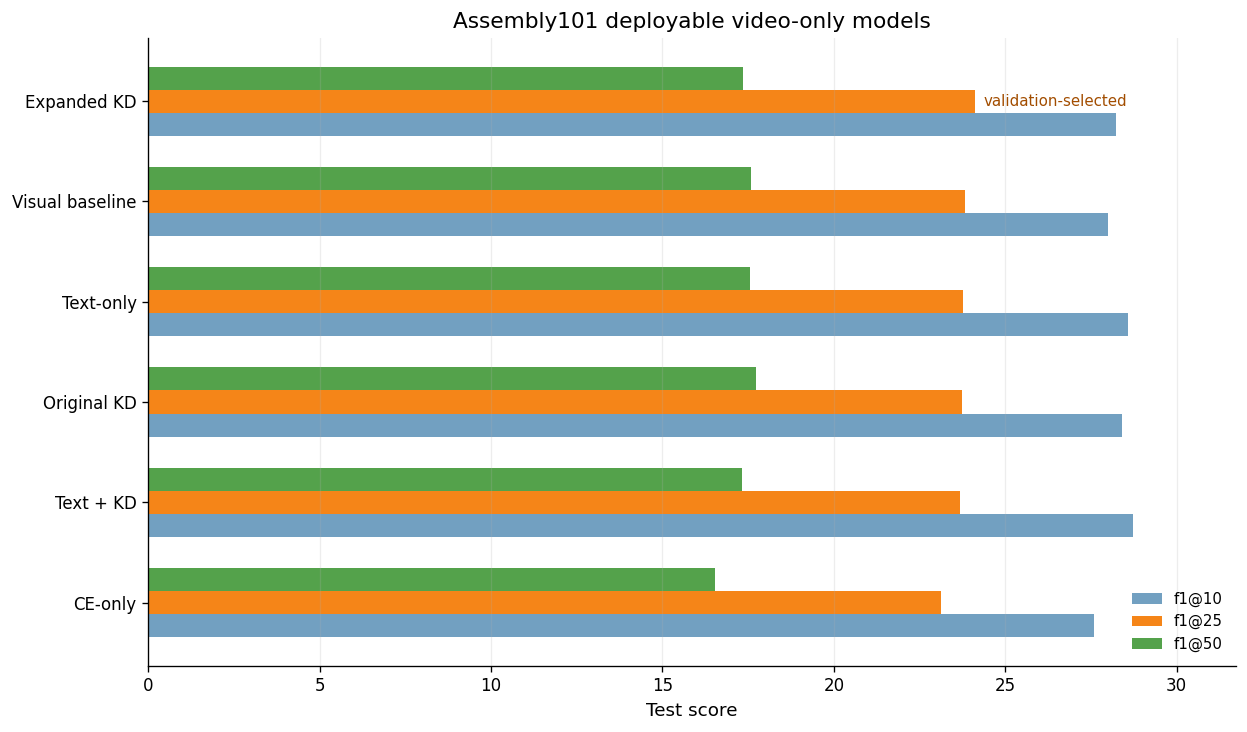

Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/figures/01_assembly_deployable_metrics.png


In [11]:
assembly_deployable_df = assembly_strategy_df[
    assembly_strategy_df["deployable"] == True
].copy()
assembly_deployable_df = assembly_deployable_df.sort_values(
    "f1@25", ascending=True
)

short_names = {
    "MS-TCN visual-only (notebook 16)": "Visual baseline",
    "MS-TCN CE-only (notebook 19)": "CE-only",
    "MS-TCN KD student (notebook 19)": "Original KD",
    "MS-TCN text-aligned student (notebook 20)": "Text-only",
    "MS-TCN selected KD student (notebook 21)": "Expanded KD",
    "MS-TCN text + KD student (notebook 21)": "Text + KD",
}
assembly_deployable_df["short_name"] = assembly_deployable_df[
    "strategy"
].map(short_names)
if assembly_deployable_df["short_name"].isna().any():
    raise RuntimeError("Missing short display name for an Assembly strategy.")

figure, axis = plt.subplots(figsize=(10.5, 6.2))
y = np.arange(len(assembly_deployable_df))
height = 0.23
plot_metrics = ["f1@10", "f1@25", "f1@50"]
plot_colors = ["#72A0C1", "#F58518", "#54A24B"]

for offset_index, (metric, color) in enumerate(
    zip(plot_metrics, plot_colors)
):
    offset = (offset_index - 1) * height
    axis.barh(
        y + offset,
        assembly_deployable_df[metric],
        height=height,
        label=metric,
        color=color,
    )

axis.set_yticks(y)
axis.set_yticklabels(assembly_deployable_df["short_name"])
axis.set_xlabel("Test score")
axis.set_title("Assembly101 deployable video-only models")
axis.grid(axis="x", alpha=0.22)
axis.legend(loc="lower right", frameon=False)
axis.set_xlim(0, max(assembly_deployable_df["f1@10"]) + 3)

selected_index = list(assembly_deployable_df["short_name"]).index(
    "Expanded KD"
)
axis.text(
    float(assembly_deployable_df.iloc[selected_index]["f1@25"]) + 0.25,
    selected_index,
    "validation-selected",
    va="center",
    fontsize=9,
    color="#A24D00",
)

figure.tight_layout()
assembly_figure_path = FIGURE_DIR / "01_assembly_deployable_metrics.png"
figure.savefig(assembly_figure_path, bbox_inches="tight")
plt.show()
print("Saved:", assembly_figure_path)


## 12. Figure — staged hyperparameter search


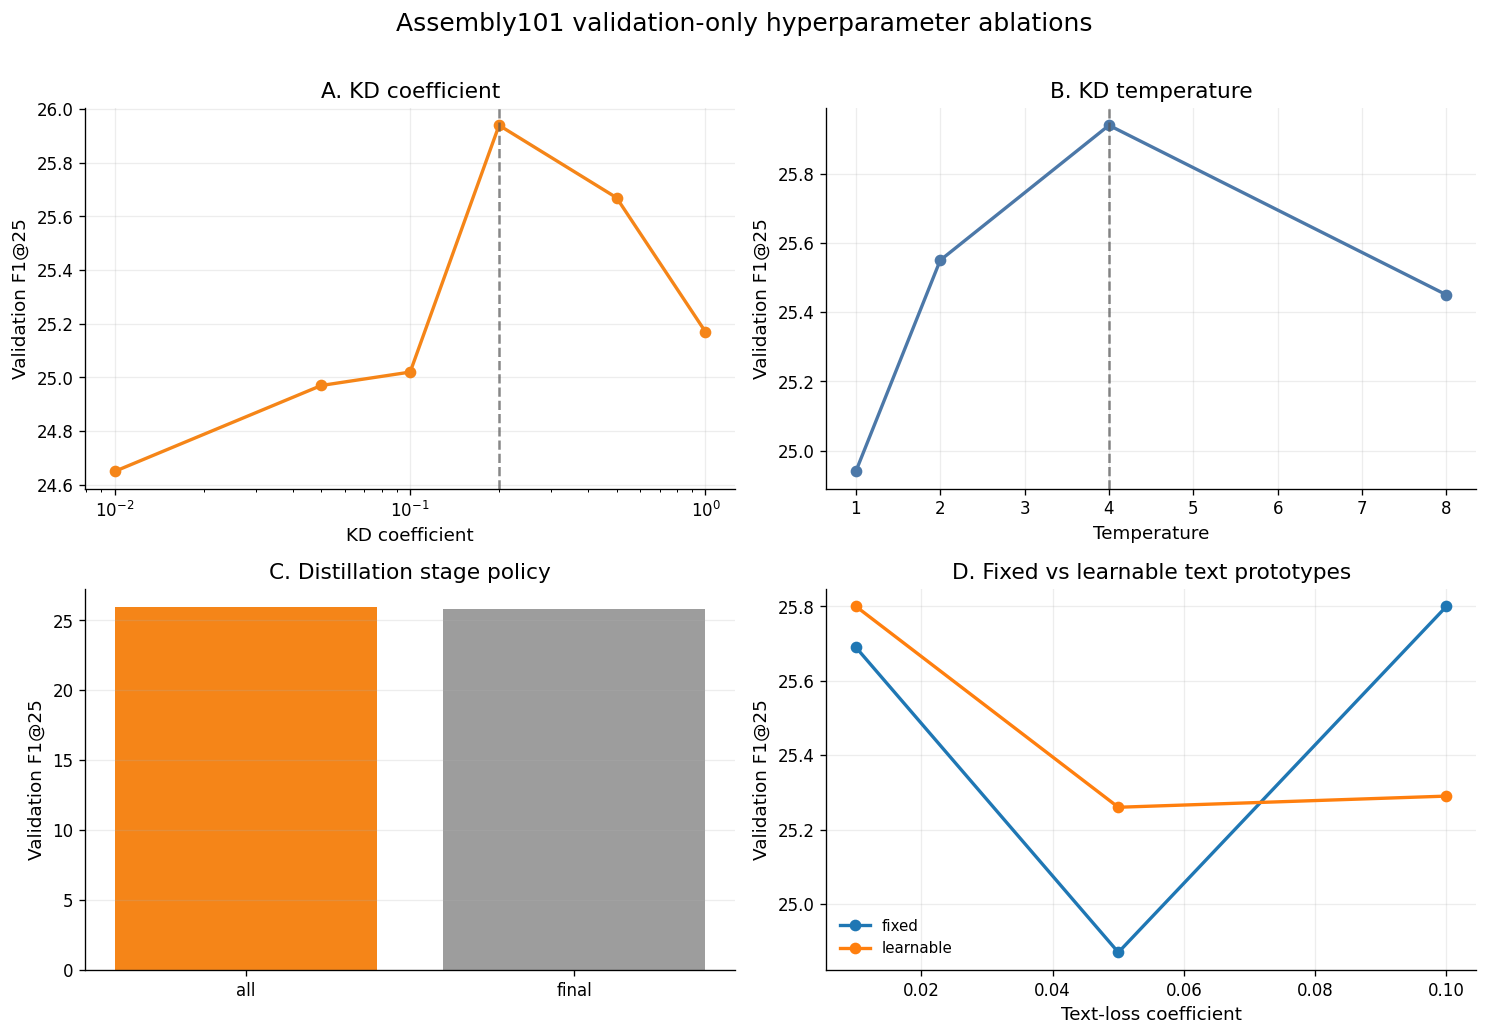

Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/figures/02_hyperparameter_ablations.png


In [12]:
figure, axes = plt.subplots(2, 2, figsize=(12.5, 8.5))

axes[0, 0].plot(
    stage_a_df["kd_lambda"],
    stage_a_df["val_f1@25"],
    marker="o",
    linewidth=2,
    color=COLORS["kd"],
)
axes[0, 0].set_xscale("log")
axes[0, 0].set_xlabel("KD coefficient")
axes[0, 0].set_ylabel("Validation F1@25")
axes[0, 0].set_title("A. KD coefficient")
axes[0, 0].grid(alpha=0.22)
axes[0, 0].axvline(0.2, color="#555555", linestyle="--", alpha=0.7)

axes[0, 1].plot(
    stage_b_df["temperature"],
    stage_b_df["val_f1@25"],
    marker="o",
    linewidth=2,
    color="#4C78A8",
)
axes[0, 1].set_xlabel("Temperature")
axes[0, 1].set_ylabel("Validation F1@25")
axes[0, 1].set_title("B. KD temperature")
axes[0, 1].grid(alpha=0.22)
axes[0, 1].axvline(4.0, color="#555555", linestyle="--", alpha=0.7)

axes[1, 0].bar(
    stage_c_df["stage_policy"],
    stage_c_df["val_f1@25"],
    color=["#F58518", "#9D9D9D"],
)
axes[1, 0].set_ylabel("Validation F1@25")
axes[1, 0].set_title("C. Distillation stage policy")
axes[1, 0].grid(axis="y", alpha=0.22)

for strategy, group in text_ablation_df.groupby("strategy"):
    axes[1, 1].plot(
        group["text_beta"],
        group["val_f1@25"],
        marker="o",
        linewidth=2,
        label=strategy,
    )
axes[1, 1].set_xlabel("Text-loss coefficient")
axes[1, 1].set_ylabel("Validation F1@25")
axes[1, 1].set_title("D. Fixed vs learnable text prototypes")
axes[1, 1].grid(alpha=0.22)
axes[1, 1].legend(frameon=False)

figure.suptitle(
    "Assembly101 validation-only hyperparameter ablations",
    fontsize=15,
    y=1.01,
)
figure.tight_layout()
hyperparameter_figure_path = FIGURE_DIR / "02_hyperparameter_ablations.png"
figure.savefig(hyperparameter_figure_path, bbox_inches="tight")
plt.show()
print("Saved:", hyperparameter_figure_path)


## 13. Figure — teacher upper bound across datasets


Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/tables/06_teacher_student_f1_25.csv
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/tables/06_teacher_student_f1_25.md


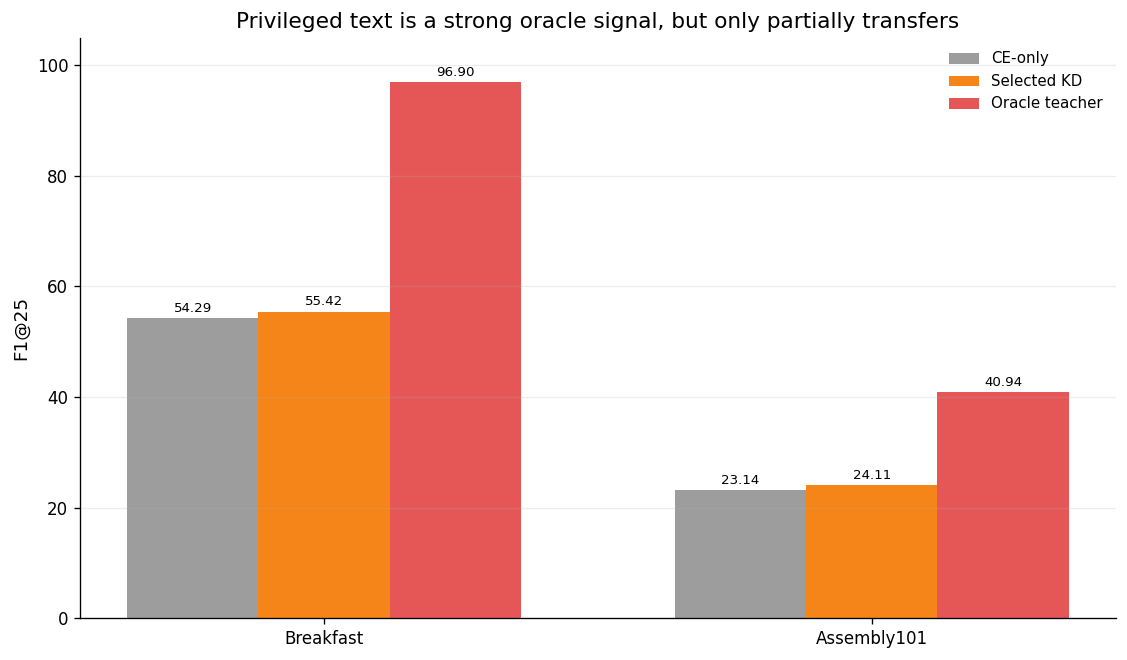

Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/figures/03_teacher_student_gap.png


In [13]:
teacher_comparison_rows = [
    {
        "dataset": "Breakfast",
        "CE-only": float(breakfast_ce_row["f1@25"]),
        "Selected KD": float(breakfast_kd_row["f1@25"]),
        "Oracle teacher": float(breakfast_teacher_row["f1@25"]),
    },
    {
        "dataset": "Assembly101",
        "CE-only": float(ce_assembly_row["f1@25"]),
        "Selected KD": float(selected_assembly_row["f1@25"]),
        "Oracle teacher": float(teacher_assembly_row["f1@25"]),
    },
]
teacher_comparison_df = pd.DataFrame(teacher_comparison_rows)
write_table(teacher_comparison_df, "06_teacher_student_f1_25")

figure, axis = plt.subplots(figsize=(9.5, 5.6))
x = np.arange(len(teacher_comparison_df))
width = 0.24
for index, (column, color) in enumerate(
    [
        ("CE-only", COLORS["ce"]),
        ("Selected KD", COLORS["kd"]),
        ("Oracle teacher", COLORS["teacher"]),
    ]
):
    bars = axis.bar(
        x + (index - 1) * width,
        teacher_comparison_df[column],
        width=width,
        label=column,
        color=color,
    )
    axis.bar_label(bars, fmt="%.2f", padding=2, fontsize=8)

axis.set_xticks(x)
axis.set_xticklabels(teacher_comparison_df["dataset"])
axis.set_ylabel("F1@25")
axis.set_title("Privileged text is a strong oracle signal, but only partially transfers")
axis.grid(axis="y", alpha=0.22)
axis.legend(frameon=False)
axis.set_ylim(0, max(teacher_comparison_df["Oracle teacher"]) + 8)

figure.tight_layout()
teacher_figure_path = FIGURE_DIR / "03_teacher_student_gap.png"
figure.savefig(teacher_figure_path, bbox_inches="tight")
plt.show()
print("Saved:", teacher_figure_path)


## 14. Figure — controlled KD gains across datasets


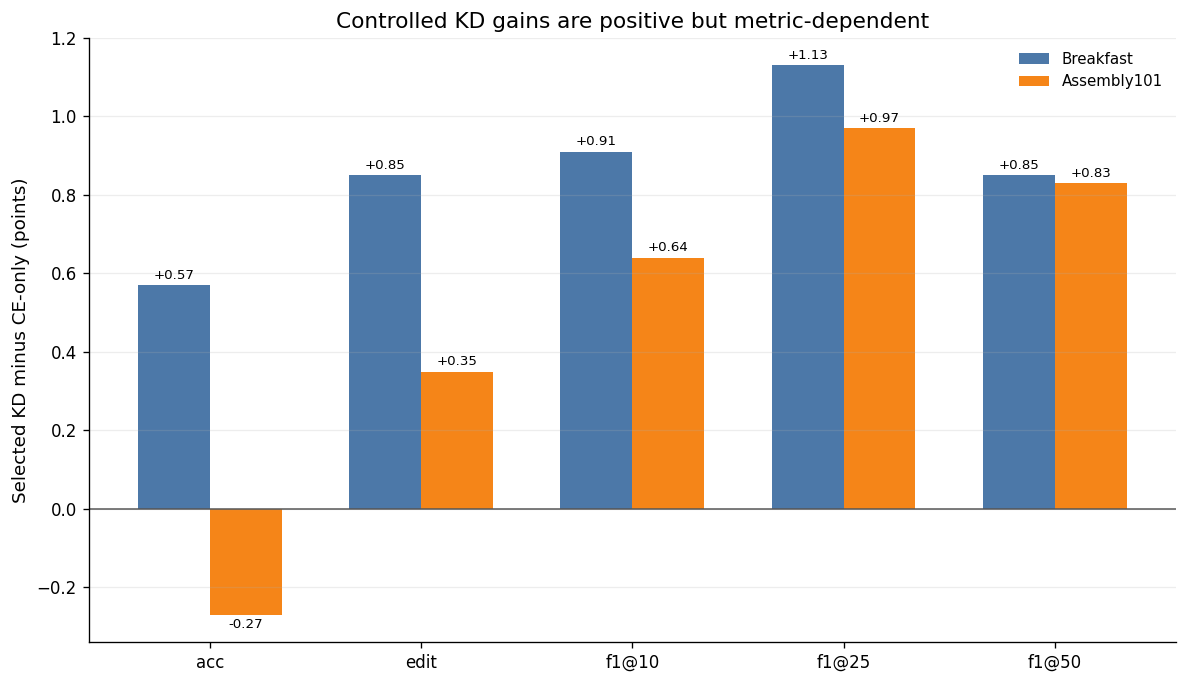

Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/figures/04_cross_dataset_kd_gains.png


In [14]:
gain_plot_df = cross_dataset_gain_df.pivot(
    index="metric", columns="dataset", values="kd_minus_ce"
).loc[METRICS]

figure, axis = plt.subplots(figsize=(10, 5.8))
x = np.arange(len(gain_plot_df.index))
width = 0.34
breakfast_bars = axis.bar(
    x - width / 2,
    gain_plot_df["Breakfast"],
    width=width,
    label="Breakfast",
    color="#4C78A8",
)
assembly_bars = axis.bar(
    x + width / 2,
    gain_plot_df["Assembly101"],
    width=width,
    label="Assembly101",
    color="#F58518",
)
axis.axhline(0, color="#555555", linewidth=0.9)
axis.set_xticks(x)
axis.set_xticklabels(gain_plot_df.index)
axis.set_ylabel("Selected KD minus CE-only (points)")
axis.set_title("Controlled KD gains are positive but metric-dependent")
axis.grid(axis="y", alpha=0.22)
axis.legend(frameon=False)
axis.bar_label(breakfast_bars, fmt="%+.2f", padding=2, fontsize=8)
axis.bar_label(assembly_bars, fmt="%+.2f", padding=2, fontsize=8)

figure.tight_layout()
gain_figure_path = FIGURE_DIR / "04_cross_dataset_kd_gains.png"
figure.savefig(gain_figure_path, bbox_inches="tight")
plt.show()
print("Saved:", gain_figure_path)


## 15. Loss definitions

For stages (s=1,dots,S), the supervised segmentation loss is

\[
\mathcal{L}_{seg}
=\sum_{s=1}^{S}
\left[
\mathcal{L}_{CE}^{(s)}
+\alpha\mathcal{L}_{smooth}^{(s)}
\right],
\qquad \alpha=0.15.
\]

Logit distillation is

\[
\mathcal{L}_{KD}
=\frac{1}{|\mathcal{S}|}
\sum_{s\in\mathcal{S}}
T^2\,
D_{KL}\!\left(
\operatorname{softmax}(z_t^{(s)}/T)
\,\Vert\,
\operatorname{softmax}(z_s^{(s)}/T)
\right).
\]

The text-alignment objective compares projected video features
(h_t) with normalized action-text prototypes (e_c):

\[
\mathcal{L}_{text}
=-\frac{1}{N}
\sum_t
\log
\frac{\exp(\tau h_t^\top e_{y_t})}
{\sum_c\exp(\tau h_t^\top e_c)}.
\]

Learnable prototypes use a regularized residual update

\[
e_c=\operatorname{norm}
\left(e_c^{CLIP}+0.1\,\Delta_c\right).
\]

The final explored objectives are

\[
\mathcal{L}_{KD\ student}
=\mathcal{L}_{seg}+\lambda_{KD}\mathcal{L}_{KD},
\]

and

\[
\mathcal{L}_{combined}
=\mathcal{L}_{seg}
+\lambda_{KD}\mathcal{L}_{KD}
+\beta_{text}\mathcal{L}_{text}
+\gamma\mathcal{L}_{anchor}.
\]

Selected Assembly101 KD configuration:
(lambda_{KD}=0.2), (T=4), all stages.


In [15]:
loss_formulas = r'''# Loss definitions

## Supervised segmentation

L_seg = sum_s [CE_s + 0.15 * L_smooth_s]

## Knowledge distillation

L_KD = mean_{s in selected stages} [T^2 * KL(teacher_T || student_T)]

Selected Assembly101 configuration: lambda_KD=0.2, T=4, all stages.

## Text-space auxiliary objective

L_text = frame-to-action-prototype contrastive cross-entropy.

Learnable prototype: normalize(CLIP_prototype + 0.1 * learnable_residual).

## Total objectives

L_KD_student = L_seg + lambda_KD * L_KD

L_combined = L_seg + lambda_KD * L_KD + beta_text * L_text + gamma * L_anchor
'''
loss_formula_path = TEXT_DIR / "loss_formulas.md"
loss_formula_path.write_text(loss_formulas, encoding="utf-8")
print("Saved:", loss_formula_path)


Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/text/loss_formulas.md


## 16. Quantitative conclusions and limitations


In [16]:
assembly_f1_gain = round(
    float(selected_assembly_row["f1@25"])
    - float(ce_assembly_row["f1@25"]),
    2,
)
breakfast_f1_gain = round(
    float(breakfast_kd_row["f1@25"])
    - float(breakfast_ce_row["f1@25"]),
    2,
)
combined_vs_text_f1 = round(
    float(combined_assembly_row["f1@25"])
    - float(text_assembly_row["f1@25"]),
    2,
)
combined_vs_kd_f1 = round(
    float(combined_assembly_row["f1@25"])
    - float(selected_assembly_row["f1@25"]),
    2,
)
teacher_gap_assembly_f1 = round(
    float(teacher_assembly_row["f1@25"])
    - float(selected_assembly_row["f1@25"]),
    2,
)

conclusions = [
    (
        "On Assembly101, MS-TCN with CLIP ViT-B/16 features is the "
        f"strongest visual-only architecture/representation pair by "
        f"test F1@25 ({best_visual_row['test_f1@25']:.2f})."
    ),
    (
        "The privileged video + ground-truth-text teacher is a strong "
        f"oracle (Assembly101 F1@25={teacher_assembly_row['f1@25']:.2f}) "
        "but is not deployable."
    ),
    (
        "The validation-selected Assembly101 student uses lambda_KD=0.2, "
        "T=4, and all-stage distillation. Its test F1@25 is "
        f"{selected_assembly_row['f1@25']:.2f}, a {assembly_f1_gain:+.2f}-point "
        "gain over the same-pipeline CE-only student."
    ),
    (
        "The text-only auxiliary student reaches nearly the same result "
        f"(F1@25={text_assembly_row['f1@25']:.2f}), showing that direct "
        "semantic alignment can transfer useful text information."
    ),
    (
        "The simple combined objective is not complementary: combined "
        f"minus text-only F1@25={combined_vs_text_f1:+.2f}, and combined "
        f"minus selected KD F1@25={combined_vs_kd_f1:+.2f}."
    ),
    (
        "Breakfast independently shows a positive controlled KD effect: "
        f"F1@25 improves by {breakfast_f1_gain:+.2f} points over CE-only."
    ),
    (
        "The large Assembly101 oracle gap remains "
        f"{teacher_gap_assembly_f1:.2f} F1@25 points, so most privileged "
        "information is not transferred by logit KD alone."
    ),
]

limitations = [
    "Final comparisons currently use one seed; small differences should not be interpreted as statistically significant.",
    "The privileged teacher receives ground-truth action text and is an oracle upper bound, not a deployable model.",
    "ProcedureVRL and CLIP features are represented at 16 temporal positions per sequence; very short actions may be under-resolved.",
    "Some early Breakfast I3D and ProcedureVRL runs use different temporal resolutions and are historical context rather than a controlled ranking.",
    "The combined objective was evaluated with separately selected weights; a larger joint search might change the result but is outside the current project scope.",
]

conclusion_text = "# Final conclusions\n\n" + "\n".join(
    f"{index + 1}. {statement}"
    for index, statement in enumerate(conclusions)
)
conclusion_text += "\n\n# Limitations\n\n" + "\n".join(
    f"- {statement}" for statement in limitations
)
conclusion_text += (
    "\n\n# Recommended final model\n\n"
    "MS-TCN video-only student with CLIP features, lambda_KD=0.2, "
    "T=4, and all-stage distillation.\n"
)

conclusion_path = TEXT_DIR / "final_conclusions_and_limitations.md"
conclusion_path.write_text(conclusion_text, encoding="utf-8")

print(conclusion_text)
print("Saved:", conclusion_path)


# Final conclusions

1. On Assembly101, MS-TCN with CLIP ViT-B/16 features is the strongest visual-only architecture/representation pair by test F1@25 (23.82).
2. The privileged video + ground-truth-text teacher is a strong oracle (Assembly101 F1@25=40.94) but is not deployable.
3. The validation-selected Assembly101 student uses lambda_KD=0.2, T=4, and all-stage distillation. Its test F1@25 is 24.11, a +0.97-point gain over the same-pipeline CE-only student.
4. The text-only auxiliary student reaches nearly the same result (F1@25=23.76), showing that direct semantic alignment can transfer useful text information.
5. The simple combined objective is not complementary: combined minus text-only F1@25=-0.09, and combined minus selected KD F1@25=-0.44.
6. Breakfast independently shows a positive controlled KD effect: F1@25 improves by +1.13 points over CE-only.
7. The large Assembly101 oracle gap remains 16.83 F1@25 points, so most privileged information is not transferred by logit KD alon

## 17. Export manifest, final summary, and ZIP archive


In [18]:
final_summary = {
    "status": "completed",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "task": "final ablation analysis and presentation artifacts",
    "training_performed": False,
    "datasets": ["Breakfast", "Assembly101"],
    "primary_metric": PRIMARY_METRIC,
    "recommended_assembly_model": {
        "architecture": "MS-TCN",
        "representation": "clip_vitb16",
        "strategy": "video-only KD student",
        "kd_lambda": float(n21["selected_kd_configuration"]["kd_lambda"]),
        "temperature": float(n21["selected_kd_configuration"]["temperature"]),
        "stage_policy": n21["selected_kd_configuration"]["stage_policy"],
        "validation_metrics": n21["selected_kd_configuration"][
            "best_validation_metrics"
        ],
        "test_metrics": n21["selected_kd_test"]["metrics"],
        "inference_input": "video only",
    },
    "main_findings": conclusions,
    "limitations": limitations,
    "protocol_audit": {
        "summaries_completed": len(summaries),
        "assembly_test_sequences": expected_test_sequences,
        "test_used_for_hyperparameter_search": False,
        "deployable_models_use_external_text": False,
        "teacher_called_at_final_inference": False,
    },
    "tables": sorted(str(path) for path in TABLE_DIR.glob("*")),
    "figures": sorted(str(path) for path in FIGURE_DIR.glob("*.png")),
    "text_artifacts": sorted(str(path) for path in TEXT_DIR.glob("*.md")),
    "source_summaries": {
        name: str(path) for name, path in SUMMARY_PATHS.items()
    },
}

final_summary_path = OUT_ROOT / "final_summary.json"
final_summary_path.write_text(
    json.dumps(final_summary, indent=2), encoding="utf-8"
)

manifest_rows = []
for category, directory in [
    ("table", TABLE_DIR),
    ("figure", FIGURE_DIR),
    ("text", TEXT_DIR),
]:
    for path in sorted(directory.glob("*")):
        if path.is_file():
            manifest_rows.append(
                {
                    "category": category,
                    "name": path.name,
                    "path": str(path),
                    "size_bytes": path.stat().st_size,
                }
            )
manifest_rows.append(
    {
        "category": "summary",
        "name": final_summary_path.name,
        "path": str(final_summary_path),
        "size_bytes": final_summary_path.stat().st_size,
    }
)
manifest_df = pd.DataFrame(manifest_rows)
manifest_path = OUT_ROOT / "artifact_manifest.csv"
manifest_df.to_csv(manifest_path, index=False)

if ARCHIVE_PATH.exists():
    ARCHIVE_PATH.unlink()
archive_created = Path(
    shutil.make_archive(
        str(ARCHIVE_PATH.with_suffix("")),
        "zip",
        root_dir=OUT_ROOT,
    )
)

display(manifest_df)
print("Saved:", final_summary_path)
print("Saved:", manifest_path)
print("Saved:", archive_created)
print("\nFinal recommended model:")
print(json.dumps(final_summary["recommended_assembly_model"], indent=2))


,category,name,path,size_bytes
0,table,00_completion_and_protocol_audit.csv,/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/tables/00_completion_and_protocol_audit.csv,1779
1,table,01_assembly_architecture_representation_grid.csv,/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/tables/01_assembly_architecture_representation_grid.csv,1530
2,table,01_assembly_architecture_representation_grid.md,/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/tables/01_assembly_architecture_representation_grid.md,3440
3,table,02_assembly_strategy_comparison.csv,/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/tables/02_assembly_strategy_comparison.csv,1050
4,table,02_assembly_strategy_comparison.md,/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/tables/02_assembly_strategy_comparison.md,2412
5,table,03_all_hyperparameter_ablations.csv,/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/tables/03_all_hyperparameter_ablations.csv,1617
6,table,03_all_hyperparameter_ablations.md,/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/tables/03_all_hyperparameter_ablations.md,2820
7,table,03a_kd_lambda_ablation.csv,/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/tables/03a_kd_lambda_ablation.csv,1995
8,table,03a_kd_lambda_ablation.md,/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/tables/03a_kd_lambda_ablation.md,3456
9,table,03b_kd_temperature_ablation.csv,/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/tables/03b_kd_temperature_ablation.csv,1489


Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/final_summary.json
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22/artifact_manifest.csv
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/final_report_artifacts/notebook22_presentation_artifacts.zip

Final recommended model:
{
  "architecture": "MS-TCN",
  "representation": "clip_vitb16",
  "strategy": "video-only KD student",
  "kd_lambda": 0.2,
  "temperature": 4.0,
  "stage_policy": "all",
  "validation_metrics": {
    "acc": 30.42,
    "edit": 26.36,
    "f1@10": 29.6,
    "f1@25": 25.94,
    "f1@50": 19.27
  },
  "test_metrics": {
    "acc": 25.67,
    "edit": 25.1,
    "f1@10": 28.22,
    "f1@25": 24.11,
    "f1@50": 17.36
  },
  "inference_input": "video only"
}


## Completion criterion

A complete run writes:

```text
.../final_report_artifacts/notebook22/
├── tables/
│   ├── 00_completion_and_protocol_audit.csv
│   ├── 01_assembly_architecture_representation_grid.csv
│   ├── 02_assembly_strategy_comparison.csv
│   ├── 03_all_hyperparameter_ablations.csv
│   ├── 04_breakfast_controlled_comparison.csv
│   └── 05_cross_dataset_kd_gains.csv
├── figures/
│   ├── 01_assembly_deployable_metrics.png
│   ├── 02_hyperparameter_ablations.png
│   ├── 03_teacher_student_gap.png
│   └── 04_cross_dataset_kd_gains.png
├── text/
│   ├── loss_formulas.md
│   ├── final_conclusions_and_limitations.md
│   ├── presentation_outline_8_slides.md
│   └── supervisor_project_update.md
├── artifact_manifest.csv
└── final_summary.json

.../final_report_artifacts/
└── notebook22_presentation_artifacts.zip
```

No model is trained or selected in this notebook. It reports the
validation decisions made in notebooks 18–21 and packages the existing
results for the final presentation.
